<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                        Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Investigación - Algoritmos de Clasificación para Detección Temprana de Abandono Laboral
        </td>
    </tr>
    <tr>
 

</table>

## Aplicación de algoritmos de clasificación para la detección temprana de abandono laboral

El conjunto de datos de predicción de rotación de empleados contiene información de 1,000 empleados, diseñado para el modelado predictivo y el análisis de la rotación laboral. Incluye una variedad de métricas demográficas, laborales y de desempeño que ayudan a comprender los factores que contribuyen a la salida o abandono de los empleados en una organización.

La variable objetivo es `Attrition`, donde:
- `No`: El empleado permanece en la empresa.
- `Yes`: El empleado dejó la empresa.

| Variable | Descripción |
|---|---|
| `Age` | Edad del empleado |
| `Gender` | Género del empleado |
| `Marital_Status` | Estado civil |
| `Department` | Departamento en que trabaja |
| `Job_Role` | Rol específico dentro del departamento |
| `Job_Level` | Nivel jerárquico |
| `Monthly_Income` | Salario mensual |
| `Hourly_Rate` | Tarifa por hora |
| `Years_at_Company` | Años en la empresa |
| `Years_in_Current_Role` | Años en el rol actual |
| `Years_Since_Last_Promotion` | Tiempo desde la última promoción |
| `Work_Life_Balance` | Valoración del equilibrio vida-trabajo |
| `Job_Satisfaction` | Satisfacción laboral (1–5) |
| `Performance_Rating` | Valoración del desempeño (1–5) |
| `Training_Hours_Last_Year` | Horas de capacitación |
| `Overtime` | Trabaja horas extra (Yes/No) |
| `Project_Count` | Número de proyectos gestionados |
| `Average_Hours_Worked_Per_Week` | Promedio de horas trabajadas por semana |
| `Absenteeism` | Días de ausencia en el último año |
| `Work_Environment_Satisfaction` | Satisfacción con el ambiente laboral |
| `Relationship_with_Manager` | Relación con el jefe inmediato |
| `Job_Involvement` | Nivel de involucramiento |
| `Distance_From_Home` | Distancia al trabajo (km) |
| `Number_of_Companies_Worked` | Número de empresas anteriores |


In [30]:
import pandas as pd
import os
import numpy as np
from pandas.core.common import flatten
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns

---
## Parte 1: Regresión Logística

### Preparación de datos

In [60]:
datos = pd.read_csv("clasificacion.csv")

In [61]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    1000 non-null   int64
 1   Age                            1000 non-null   int64
 2   Gender                         1000 non-null   str  
 3   Marital_Status                 1000 non-null   str  
 4   Department                     1000 non-null   str  
 5   Job_Role                       1000 non-null   str  
 6   Job_Level                      1000 non-null   int64
 7   Monthly_Income                 1000 non-null   int64
 8   Hourly_Rate                    1000 non-null   int64
 9   Years_at_Company               1000 non-null   int64
 10  Years_in_Current_Role          1000 non-null   int64
 11  Years_Since_Last_Promotion     1000 non-null   int64
 12  Work_Life_Balance              1000 non-null   int64
 13  Job_Satisfaction              

In [62]:
datos.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


### Variable objetivo del estudio

La variable Attrition representa el abandono laboral dentro de la organización. Esta variable indica si un empleado permanece trabajando en la empresa o si ha decidido abandonarla.

Debido a que únicamente presenta dos posibles categorías, el problema corresponde a una clasificación binaria. Por esta razón se utilizarán algoritmos de clasificación supervisada para identificar patrones asociados al abandono laboral.

In [63]:
# Eliminar columna ID y codificar variables categóricas
datos_rl = datos.drop(["Employee_ID"], axis=1)

# Codificar variables categóricas binarias
datos_rl["Gender"] = [1 if x == "Male" else 0 for x in datos_rl["Gender"]]
datos_rl["Overtime"] = [1 if x == "Yes" else 0 for x in datos_rl["Overtime"]]

# Codificar variable objetivo
datos_rl["Attrition"] = [1 if x == "Yes" else 0 for x in datos_rl["Attrition"]]

# Codificar variables categóricas nominales con get_dummies
datos_rl = pd.get_dummies(datos_rl, columns=["Marital_Status", "Department", "Job_Role"], drop_first=True)

datos_rl.head()

,Age,Gender,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Attrition,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager
0,58,0,1,15488,28,15,4,2,1,3,...,0,True,False,False,True,False,False,False,False,True
1,48,0,5,13079,28,6,9,1,2,1,...,0,True,False,False,False,False,True,True,False,False
2,34,1,1,13744,24,24,14,8,3,2,...,0,True,False,False,False,True,False,True,False,False
3,27,0,1,6809,26,10,8,2,3,5,...,0,False,False,False,False,True,False,False,False,True
4,40,1,1,10206,52,29,10,1,2,5,...,0,False,False,False,False,True,False,False,True,False


In [64]:
X_independientes = datos_rl.drop(["Attrition"], axis=1)
y_dependiente = datos_rl["Attrition"]

<Figure size 640x480 with 0 Axes>

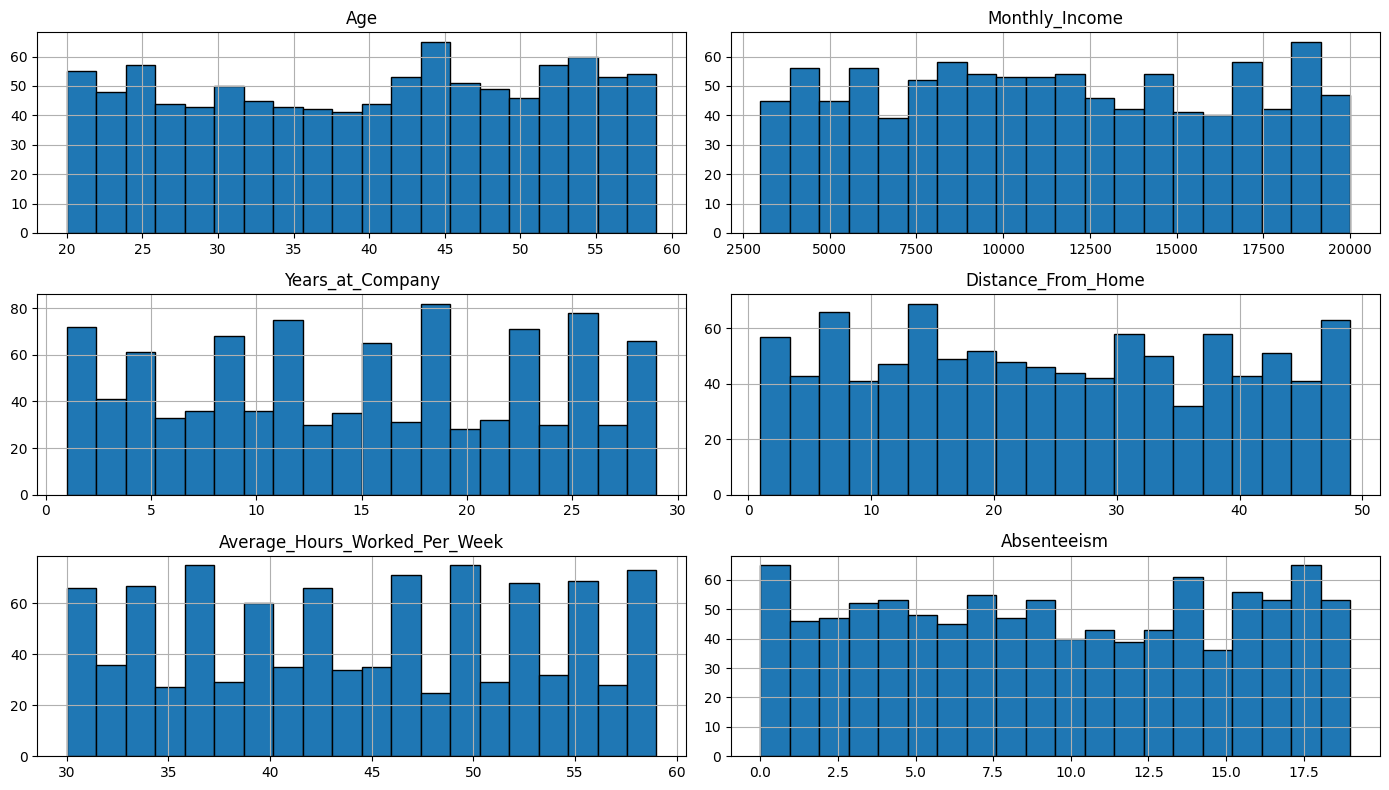

In [65]:
# Análisis gráfico de variables numéricas
plt.figure()
X_independientes[["Age", "Monthly_Income", "Years_at_Company", "Distance_From_Home",
                   "Average_Hours_Worked_Per_Week", "Absenteeism"]].hist(figsize=(14,8), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_independientes, y_dependiente, test_size=0.25, random_state=2026)

### Entrenamiento del modelo

In [67]:
from sklearn.linear_model import LogisticRegression

model_rl = LogisticRegression(max_iter=1000, random_state=2026)
model_rl.fit(X_train, y_train)

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Regresión Logística

La Regresión Logística es un algoritmo de clasificación supervisada utilizado cuando la variable respuesta presenta únicamente dos posibles categorías.

En esta investigación se emplea para predecir la variable Attrition, la cual indica si un empleado abandonó o no la organización. El objetivo consiste en identificar patrones asociados al abandono laboral utilizando las variables demográficas, laborales y de desempeño disponibles en el conjunto de datos.

### Predicción

In [68]:
y_pred_rl = model_rl.predict(X_test)

### Accuracy Score

In [69]:
from sklearn.metrics import accuracy_score

accuracy_rl = accuracy_score(y_test, y_pred_rl)
print("El accuracy score que se tiene es %s" %accuracy_rl)

El accuracy score que se tiene es 0.8


### Matriz de Confusión

Text(50.722222222222214, 0.5, 'Real')

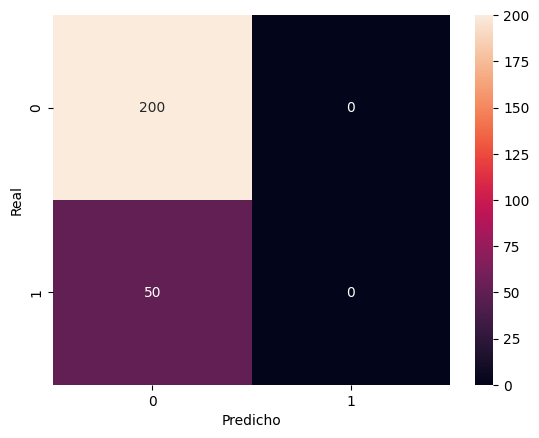

In [70]:
from sklearn.metrics import confusion_matrix

cm_rl = confusion_matrix(y_test, y_pred_rl)
sns.heatmap(cm_rl, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

### Precisión, Recall y F1 Score

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rl = precision_score(y_test, y_pred_rl)
recall_rl = recall_score(y_test, y_pred_rl)
f1_rl = f1_score(y_test, y_pred_rl)

metricas_rl = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_rl, recall_rl, f1_rl]})
metricas_rl

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Métricas,Valores
0,Precisión,0.0
1,Recall,0.0
2,F1,0.0


In [78]:
print(y_train.value_counts())
print(y_test.value_counts())

Attrition
0    611
1    139
Name: count, dtype: int64
Attrition
0    200
1     50
Name: count, dtype: int64


In [79]:
print(y_pred_rl[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


---
## Parte 2: KNN (K-Nearest Neighbors)

### Preparación de datos

In [43]:
datos_knn = datos.drop(["Employee_ID"], axis=1)

datos_knn["Gender"] = [1 if x == "Male" else 0 for x in datos_knn["Gender"]]
datos_knn["Overtime"] = [1 if x == "Yes" else 0 for x in datos_knn["Overtime"]]
datos_knn["Attrition"] = [1 if x == "Yes" else 0 for x in datos_knn["Attrition"]]
datos_knn = pd.get_dummies(datos_knn, columns=["Marital_Status", "Department", "Job_Role"], drop_first=True)

X_independientes_knn = datos_knn.drop(["Attrition"], axis=1)
y_dependiente_knn = datos_knn["Attrition"]

<Figure size 640x480 with 0 Axes>

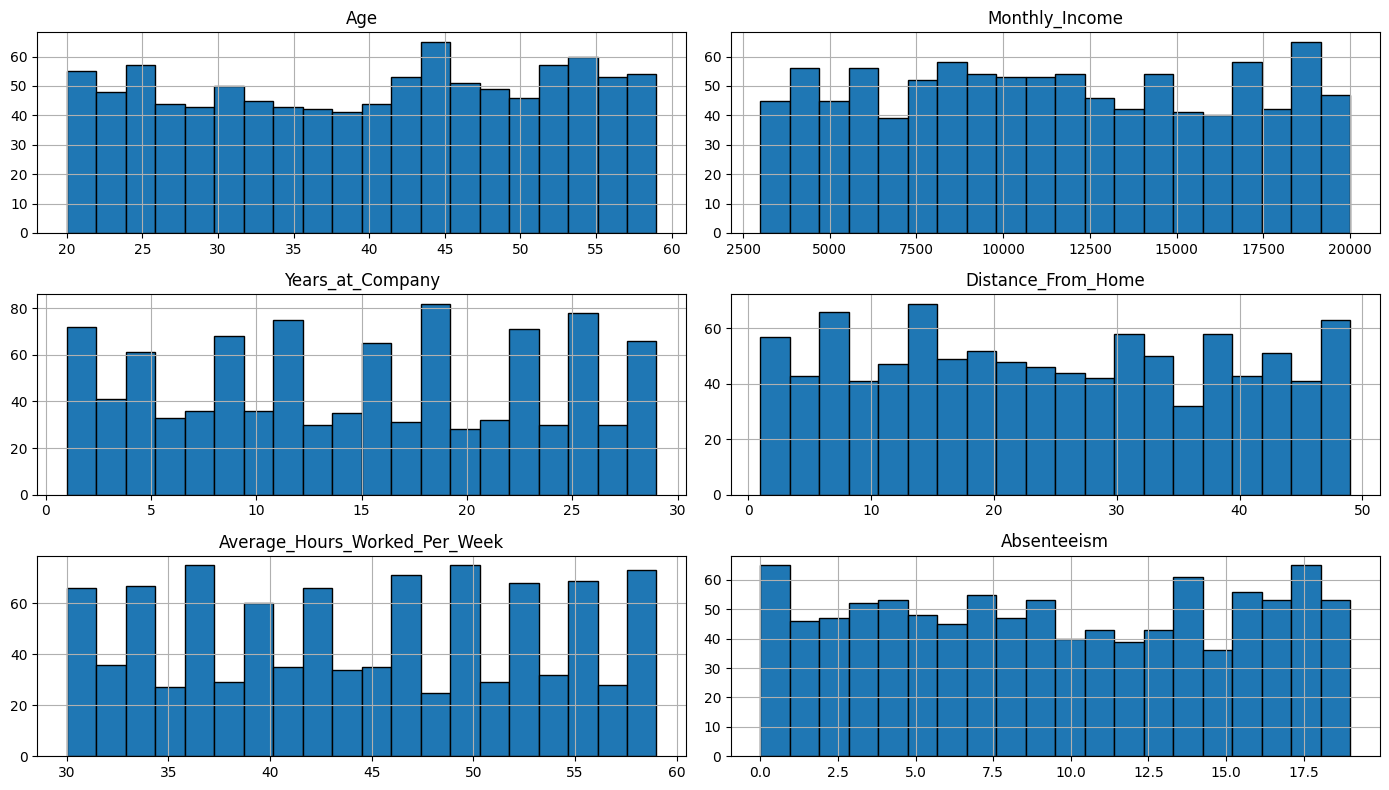

In [44]:
# Análisis gráfico
plt.figure()
X_independientes_knn[["Age", "Monthly_Income", "Years_at_Company", "Distance_From_Home",
                        "Average_Hours_Worked_Per_Week", "Absenteeism"]].hist(figsize=(14,8), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

### Estandarización de variables

In [45]:
from sklearn.preprocessing import StandardScaler

escalar = StandardScaler()
escalar.fit(X_independientes_knn)

X_independientes_est = escalar.transform(X_independientes_knn)

In [46]:
from sklearn.model_selection import train_test_split

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_independientes_est, y_dependiente_knn, test_size=0.25, random_state=2026)

### Modelo KNN con k=10

In [47]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN_10 = KNeighborsClassifier(n_neighbors=10)
model_KNN_10.fit(X_train_knn, y_train_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
from sklearn.metrics import accuracy_score

y_pred_10 = model_KNN_10.predict(X_test_knn)
accuracy_10 = accuracy_score(y_test_knn, y_pred_10)
print("El accuracy score que se tiene es %s" %accuracy_10)

El accuracy score que se tiene es 0.8


Text(50.722222222222214, 0.5, 'Real')

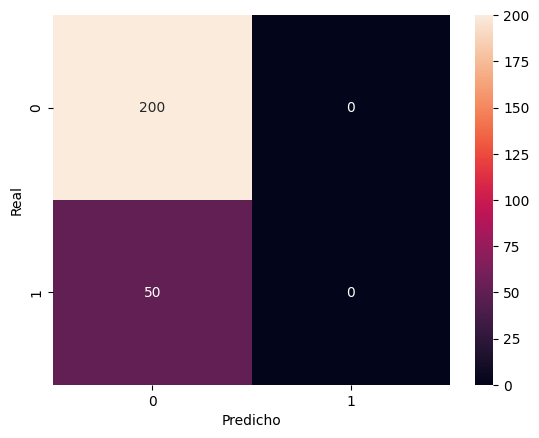

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_knn, y_pred_10)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_10 = precision_score(y_test_knn, y_pred_10)
recall_10 = recall_score(y_test_knn, y_pred_10)
f1_10 = f1_score(y_test_knn, y_pred_10)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_10, recall_10, f1_10]})
metricas

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Métricas,Valores
0,Precisión,0.0
1,Recall,0.0
2,F1,0.0


### Modelo KNN con k=50

In [51]:
model_KNN_50 = KNeighborsClassifier(n_neighbors=50)
model_KNN_50.fit(X_train_knn, y_train_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [52]:
y_pred_50 = model_KNN_50.predict(X_test_knn)
accuracy_50 = accuracy_score(y_test_knn, y_pred_50)
print("El accuracy score que se tiene es %s" %accuracy_50)

El accuracy score que se tiene es 0.8


Text(50.722222222222214, 0.5, 'Real')

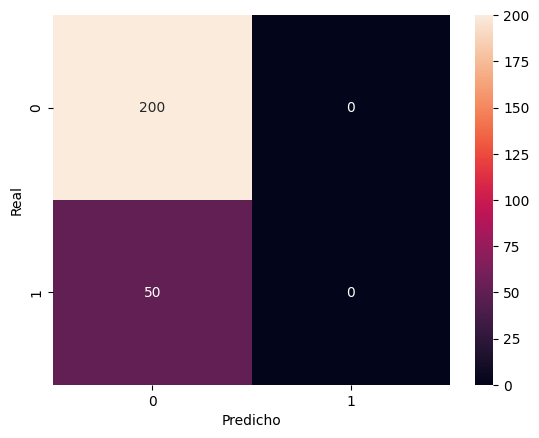

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_knn, y_pred_50)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [54]:
precision_50 = precision_score(y_test_knn, y_pred_50)
recall_50 = recall_score(y_test_knn, y_pred_50)
f1_50 = f1_score(y_test_knn, y_pred_50)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_50, recall_50, f1_50]})
metricas

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Métricas,Valores
0,Precisión,0.0
1,Recall,0.0
2,F1,0.0


### Búsqueda del mejor K mediante validación cruzada

In [55]:
# Encontrar el valor optimo de K
from sklearn.model_selection import cross_val_score
#Valores de K que vamos a probar

k_range = range(1, 100)
#Inicializar vector de puntuaciones
k_scores = []
# bucle
for k in k_range:
    # ajustar el modelo con k vecinos
    knn = KNeighborsClassifier(n_neighbors=k)
    # obtener puntuaciones de VC
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=10, scoring="accuracy")
    # Guardar puntuaciones en el vector
    k_scores.append(scores.mean())

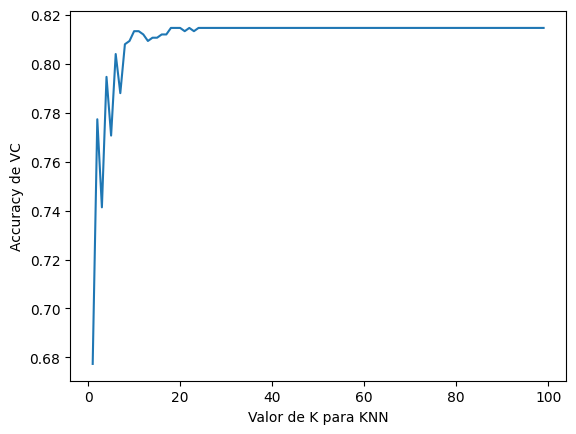

In [56]:
#Representar la validación cruzada
plt.plot(k_range, k_scores)
plt.xlabel('Valor de K para KNN')
plt.ylabel('Accuracy de VC')
plt.show()

In [57]:
print("El valor de K que maximiza la accuracy es", np.argmax(k_scores) + 1)

El valor de K que maximiza la accuracy es 18


### Entrenamiento con el K óptimo

In [ ]:
k_optimo = np.argmax(k_scores) + 1

model_KNN_opt = KNeighborsClassifier(n_neighbors=k_optimo)
model_KNN_opt.fit(X_train_knn, y_train_knn)

In [ ]:
y_pred_opt = model_KNN_opt.predict(X_test_knn)
accuracy_opt = accuracy_score(y_test_knn, y_pred_opt)
print("El accuracy score que se tiene es %s" %accuracy_opt)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_knn, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [ ]:
precision_opt = precision_score(y_test_knn, y_pred_opt)
recall_opt = recall_score(y_test_knn, y_pred_opt)
f1_opt = f1_score(y_test_knn, y_pred_opt)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_opt, recall_opt, f1_opt]})
metricas

### Predicción para la mediana de las variables independientes

In [ ]:
#Con el valor de k encontrado se realizará una clasificación para la mediana de todas las variables

medianas_x = np.median(X_train_knn, axis=0)
model_KNN_opt.predict(medianas_x.reshape(1,-1))

### Comparación de resultados KNN

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["KNN k=10", "KNN k=50", "KNN k=óptimo"],
    "Accuracy": [accuracy_10, accuracy_50, accuracy_opt],
    "Precisión": [precision_10, precision_50, precision_opt],
    "Recall": [recall_10, recall_50, recall_opt],
    "F1": [f1_10, f1_50, f1_opt]
})
comparacion

---
## Parte 3: Árboles de Decisión

### Preparación de datos

In [ ]:
datos_arbol = datos.drop(["Employee_ID"], axis=1)

datos_arbol["Gender"] = [1 if x == "Male" else 0 for x in datos_arbol["Gender"]]
datos_arbol["Overtime"] = [1 if x == "Yes" else 0 for x in datos_arbol["Overtime"]]
datos_arbol["Attrition"] = [1 if x == "Yes" else 0 for x in datos_arbol["Attrition"]]
datos_arbol = pd.get_dummies(datos_arbol, columns=["Marital_Status", "Department", "Job_Role"], drop_first=True)

X_independientes_arbol = datos_arbol.drop(["Attrition"], axis=1)
y_dependiente_arbol = datos_arbol["Attrition"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_independientes_arbol, y_dependiente_arbol, test_size=0.25, random_state=2026)

### a) Árbol de decisión con parámetros por defecto

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#Crear el objeto de clase árbol con los parámetros por defecto
tree_clf = DecisionTreeClassifier(random_state=2026)
#Ajustar el arbol
tree_clf.fit(X_train_a, y_train_a);

In [ ]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf, filled=True)

In [ ]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test_a)
accuracy_a = accuracy_score(y_test_a, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

In [ ]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test_a, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_1 = precision_score(y_test_a, y_pred_a)
recall_1 = recall_score(y_test_a, y_pred_a)
f1_1 = f1_score(y_test_a, y_pred_a)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_1, recall_1, f1_1]})
metricas

### b) Árbol de decisión con profundidad máxima de 3

In [ ]:
#Crear el objeto de clase árbol usando una profundidad máxima de 3
tree_clf_b = DecisionTreeClassifier(max_depth=3, random_state=2026)
#Ajustar el arbol
tree_clf_b.fit(X_train_a, y_train_a);

In [ ]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_b, filled=True)

In [ ]:
#Obtener el accuracy_score
y_pred_b = tree_clf_b.predict(X_test_a)
accuracy_b = accuracy_score(y_test_a, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

In [ ]:
from sklearn.metrics import confusion_matrix
#Obtener la matriz de confusión
cm = confusion_matrix(y_test_a, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_b = precision_score(y_test_a, y_pred_b)
recall_b = recall_score(y_test_a, y_pred_b)
f1_b = f1_score(y_test_a, y_pred_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b, f1_b]})
metricas

### c) Árbol de decisión con máximo de nodos hoja de 10

In [ ]:
from sklearn.tree import DecisionTreeClassifier
#Crear el objeto de clase árbol usando una profundidad máxima de 10
tree_clf_c = DecisionTreeClassifier(max_leaf_nodes=10, random_state=2026)
#Ajustar el arbol
tree_clf_c.fit(X_train_a, y_train_a);

In [ ]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_c, filled=True)

In [ ]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_c = tree_clf_c.predict(X_test_a)
accuracy_c = accuracy_score(y_test_a, y_pred_c)
print("El accuracy score que se tiene es %s" %accuracy_c)

In [ ]:
from sklearn.metrics import confusion_matrix
#Obtener la matriz de confusión
cm = confusion_matrix(y_test_a, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_c = precision_score(y_test_a, y_pred_c)
recall_c = recall_score(y_test_a, y_pred_c)
f1_c = f1_score(y_test_a, y_pred_c)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_c, recall_c, f1_c]})
metricas

### d) Validación cruzada para determinar la profundidad máxima óptima

In [ ]:
#Realizar la validación cruzada

from sklearn import tree
from sklearn.model_selection import cross_val_score

k_range = range(3, 20)
depth = list()
for i in k_range:
    clf = tree.DecisionTreeClassifier(max_depth=i, random_state=2026)
    scores = cross_val_score(estimator=clf, X=X_train_a, y=y_train_a, cv=10, n_jobs=4)
    depth.append(scores.mean())
print(depth)

In [ ]:
#Representar la validación cruzada
plt.plot(k_range, depth)
plt.xlabel('Valor de la profundidad máxima')
plt.ylabel('Accuracy de VC')
plt.show()

In [ ]:
print("El valor de K que maximiza la accuracy es", np.argmax(depth) + 3)

### e) Árbol con la profundidad óptima — clasificación para la media de las variables

In [ ]:
from sklearn.tree import DecisionTreeClassifier

prof_optima = np.argmax(depth) + 3

#Crear el objeto de clase árbol con la profundidad óptima
tree_clf_d = DecisionTreeClassifier(max_depth=prof_optima, random_state=2026)
#Ajustar el arbol
tree_clf_d.fit(X_train_a, y_train_a);

In [ ]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_d = tree_clf_d.predict(X_test_a)
accuracy_d = accuracy_score(y_test_a, y_pred_d)
print("El accuracy score que se tiene es %s" %accuracy_d)

In [ ]:
from sklearn.metrics import confusion_matrix
#Obtener la matriz de confusión
cm = confusion_matrix(y_test_a, y_pred_d)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_d = precision_score(y_test_a, y_pred_d)
recall_d = recall_score(y_test_a, y_pred_d)
f1_d = f1_score(y_test_a, y_pred_d)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_d, recall_d, f1_d]})
metricas

In [ ]:
#Obtener la media para clasificar
X_media = np.mean(X_train_a, axis=0)
#Realizar la clasificación
media_clf = tree_clf_d.predict(X_media.values.reshape(1,-1))
print("El empleado se clasifica como %s" %media_clf)

### Comparación de resultados — Árboles de Decisión

In [ ]:
comparacion_arboles = pd.DataFrame({
    "Modelo": ["Por defecto", "max_depth=3", "max_leaf_nodes=10", "depth óptima"],
    "Accuracy": [accuracy_a, accuracy_b, accuracy_c, accuracy_d],
    "Precisión": [precision_1, precision_b, precision_c, precision_d],
    "Recall": [recall_1, recall_b, recall_c, recall_d],
    "F1": [f1_1, f1_b, f1_c, f1_d]
})
comparacion_arboles